In [1]:
# Import of all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, make_scorer

### Data Preparation

In [35]:
# Setting structural headers (A1 to A16)
column_names = [f"A{i}" for i in range(1, 17)]

In [37]:
# Loading the file, map headers, and identifying missing indicators ('?')
df = pd.read_csv(local_file, names=column_names, na_values="?")

In [39]:
# Confirming the data has loaded correctly
print(f"Data successfully loaded from local folder!")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
print(df.head())

Data successfully loaded from local folder!
Total Rows: 690, Total Columns: 16
  A1     A2     A3 A4 A5 A6 A7    A8 A9 A10  A11 A12 A13    A14  A15 A16
0  b  30.83  0.000  u  g  w  v  1.25  t   t    1   f   g  202.0    0   +
1  a  58.67  4.460  u  g  q  h  3.04  t   t    6   f   g   43.0  560   +
2  a  24.50  0.500  u  g  q  h  1.50  t   f    0   f   g  280.0  824   +
3  b  27.83  1.540  u  g  w  v  3.75  t   t    5   t   g  100.0    3   +
4  b  20.17  5.625  u  g  w  v  1.71  t   f    0   f   s  120.0    0   +


### Exploratory Data Analysis

In [41]:
# checking missing values in each column
print(df.isnull().sum())

A1     12
A2     12
A3      0
A4      6
A5      6
A6      9
A7      9
A8      0
A9      0
A10     0
A11     0
A12     0
A13     0
A14    13
A15     0
A16     0
dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_6296\621016864.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="A16", data=df, ax=axes[0], palette="Set1")


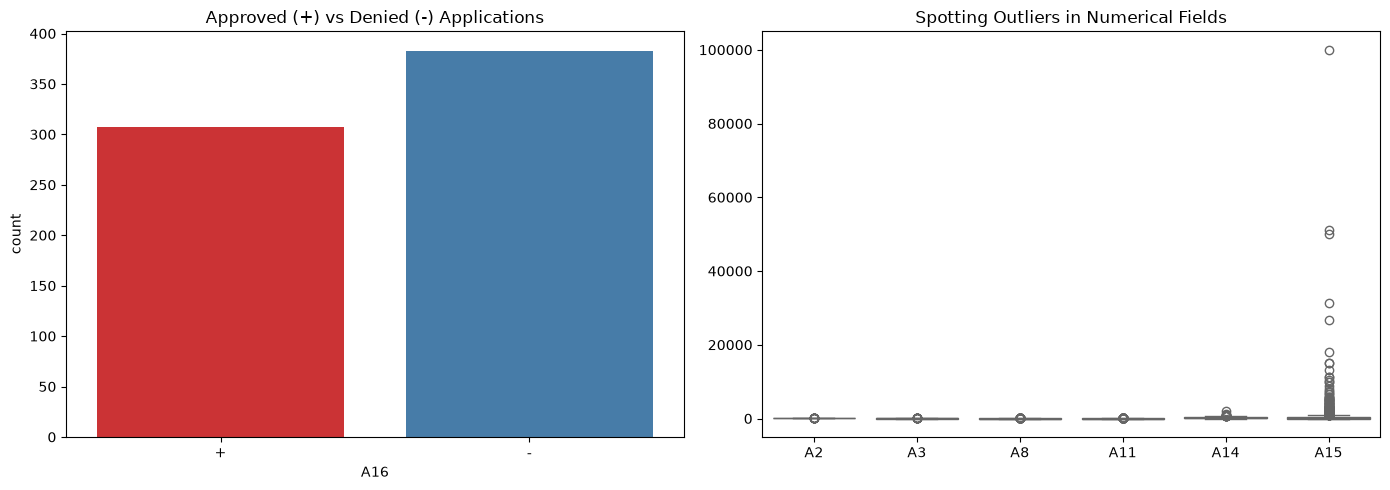

In [45]:
# Creating a figure canvas with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Visualizing the target results (Approved vs Denied)
sns.countplot(x="A16", data=df, ax=axes[0], palette="Set1")
axes[0].set_title("Approved (+) vs Denied (-) Applications")

# Chart 2: Checking for extreme outlier spikes in numerical columns
sns.boxplot(data=df.select_dtypes(include=[np.number]), ax=axes[1], palette="Set3")
axes[1].set_title("Spotting Outliers in Numerical Fields")

plt.tight_layout()
plt.show()


### Preprocessing

In [49]:
# separating the questions (X) from the final decision answer (y)
X = df.drop(columns=["A16"])
y = df["A16"]

In [51]:
# Categorizing columns into numeric lists and text lists
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

In [57]:
# Strategies to fix missing data values by adding median to numerical values and mean to categorical values
num_imp = SimpleImputer(strategy="median")
cat_imp = SimpleImputer(strategy="most_frequent")

# Filling in the missing data across both column data types
X[num_cols] = num_imp.fit_transform(X[num_cols])
X[cat_cols] = cat_imp.fit_transform(X[cat_cols])

print("Missing values have been successfully handled!")

Missing values have been successfully handled!


In [65]:
# capping outliers at the 1st and 99th percentiles to smooth spikes
for col in num_cols:
    X[col] = np.clip(X[col], X[col].quantile(0.01), X[col].quantile(0.99))

# Transforming all categorical text attributes into simple numbers
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print("Outliers capped and categories converted to numbers!")

Outliers capped and categories converted to numbers!


### Feature Selection

In [67]:
# Scaling all features to match a uniform variance size format
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Displaying the top 3 rows of the fully prepared dataset
X_scaled.head(3)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,0.661438,-0.054774,-0.975680,-0.54295,-0.559499,1.471393,0.757878,-0.298489,0.95465,1.157144,-0.324178,-0.919195,-0.317171,0.143685,-0.343700
1,-1.511858,2.331231,-0.054643,-0.54295,-0.559499,1.004392,-0.836439,0.276514,0.95465,1.157144,0.948192,-0.919195,-0.317171,-0.902343,-0.085700
2,-1.511858,-0.597281,-0.872425,-0.54295,-0.559499,1.004392,-0.836439,-0.218181,0.95465,-0.864196,-0.578651,-0.919195,-0.317171,0.656830,0.035929


###  Engineering

In [71]:
# Splitting data into training (80%) and testing (20%) data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Model creation and evaluation

In [73]:
# Logistic Regression model
model_a = LogisticRegression(random_state=42)
model_a.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [85]:
# Generating predictions on the test set
preds_a = model_a.predict(X_test)
acc_a = accuracy_score(y_test, preds_a)
f1_a = f1_score(y_test, preds_a, pos_label='+')

# Computing and generating performance scores
print(f"Model A (Baseline) -> Accuracy: {acc_a:.2%}, F1-Score: {f1_a:.2%}")

Model A (Baseline) -> Accuracy: 83.33%, F1-Score: 83.69%


### 📝 Metric Justification for Task 4. a)
* **Accuracy**: The accuracy metric was used to show the overall percentage of correct credit decisions.
* **F1-Score**: The F1-Score balance catching risky applications and approving safe customers.